# Komparasi Algoritma Machine Learning Klasik dan IndoBERT dengan Explainable AI (SHAP) untuk Klasifikasi Tingkat Keparahan Depresi pada Unggahan Media Sosial X Berbahasa Indonesia

**Notebook ini adalah implementasi kode siap-pakai (ready-to-use) untuk Google Colab dengan runtime GPU NVIDIA T4 (16GB).**

Notebook ini **konsisten penuh** dengan dokumen berikut pada vault Obsidian *Psikologi Komputasional Indonesia*:
- `03_Proposal_Penelitian.md` — judul, rumusan masalah (RQ1–RQ3), variabel, hipotesis (H0/H1)
- `04_Desain_Eksperimen.md` — skema validasi, tabel parameter konfigurasi, flowchart, rencana stress testing

> **Cara pakai cepat:** Runtime → Change runtime type → pilih **GPU (T4)** → Run all.
> Notebook berjalan secara default dalam **`QUICK_DEMO_MODE = True`** (memakai data sintetis & grid kecil) agar bisa dieksekusi end-to-end dalam beberapa menit untuk verifikasi pipeline. Untuk eksperimen riil sesuai desain penuh, ganti dataset pada Bagian 3 dan set `QUICK_DEMO_MODE = False` pada Bagian 2.

## Daftar Isi
0. Pemeriksaan Lingkungan (GPU)
1. Instalasi Dependencies
2. Import & Konfigurasi Reproducibility
3. Dataset (Data Asli / Sintetis untuk Demo)
4. Preprocessing NLP (Sastrawi)
5. Pembagian Data: Hold-out 80:20 + Stratified 5-Fold CV
6. Ekstraksi Fitur TF-IDF
7. Fungsi SMOTE (anti-leakage, hanya pada training fold)
8. Model ML Klasik: Random Forest, SVM, XGBoost
9. Model IndoBERT — Fine-tuning
10. Agregasi Hasil Cross-Validation
11. Model Final & Evaluasi Held-out Test Set
12. Explainable AI — SHAP
13. Uji Hipotesis Statistik (H0/H1)
14. Stress Testing & Analisis Skalabilitas
15. Visualisasi & Ekspor Laporan


## 0. Pemeriksaan Lingkungan (GPU Check)
Memastikan runtime Colab terhubung ke GPU NVIDIA T4 sesuai spesifikasi hardware pada `04_Desain_Eksperimen.md §4`.

In [2]:
!nvidia-smi
import torch
print("\n=== Status PyTorch & CUDA ===")
print("PyTorch version :", torch.__version__)
print("CUDA tersedia   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nama GPU        :", torch.cuda.get_device_name(0))
    print("VRAM total (GB) :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print("⚠️ GPU tidak terdeteksi. Buka menu Runtime > Change runtime type > pilih GPU (T4).")


Sun Jul 19 16:10:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalasi Dependencies
Sesuai tabel software pada `04_Desain_Eksperimen.md §4`. Sebagian besar sudah tersedia di Colab; baris di bawah memastikan versi minimum & pustaka tambahan (SHAP, imbalanced-learn, Sastrawi, XGBoost) terpasang.

In [3]:
!pip install -q -U "transformers>=4.40" "datasets>=2.18" "accelerate>=0.28" \
    "scikit-learn>=1.3" "xgboost>=2.0" "imbalanced-learn>=0.12" "shap>=0.45" \
    "Sastrawi>=1.0.1" "sentencepiece" "seaborn" "psutil"
print("✅ Instalasi selesai.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.9 MB/s eta 0:00:00
✅ Instalasi selesai.


## 2. Import Library & Konfigurasi Reproducibility
`random_state = 42` diterapkan secara global sebagai **variabel kontrol** (lihat `03_Proposal_Penelitian.md §6`) agar seluruh perbandingan model adil (apple-to-apple).

Atur `QUICK_DEMO_MODE`:
- `True`  → grid kecil, 2-fold, data sintetis ±800 sampel, IndoBERT 1 epoch → selesai dalam beberapa menit (untuk verifikasi pipeline).
- `False` → grid PENUH & 5-fold sesuai `04_Desain_Eksperimen.md §5` (tabel parameter), gunakan dataset riil Anda → durasi bisa berjam-jam tergantung ukuran data.

In [4]:
import os, re, time, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------
# KONFIGURASI GLOBAL (variabel kontrol — 03_Proposal_Penelitian.md §6)
# ---------------------------------------------------------------
SEED = 42
LABELS = ["Tidak Ada", "Ringan", "Sedang", "Berat"]   # label ordinal 4 kelas (PHQ-9 derived)
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

QUICK_DEMO_MODE = False   # <<< UBAH ke False untuk eksperimen penuh sesuai desain riset

if QUICK_DEMO_MODE:
    N_FOLDS = 2
    BERT_EPOCHS = 1
    SYNTH_N_SAMPLES = 800
    SEARCH_MODE = "random"
    N_ITER_SEARCH = 6
else:
    N_FOLDS = 5
    BERT_EPOCHS = 4
    SYNTH_N_SAMPLES = 6000
    SEARCH_MODE = "grid"
    N_ITER_SEARCH = None

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUTPUT_DIR = "/content/drive/MyDrive/lia/outputs_depresi_id"
    print("✅ Google Drive ter-mount. OUTPUT_DIR diarahkan ke Drive (PERSISTEN antar sesi).")
except ImportError:
    OUTPUT_DIR = "/content/outputs_depresi_id"
    print("⚠️  Bukan di Colab (atau Drive tidak tersedia) — OUTPUT_DIR memakai path lokal "
          "yang TIDAK persisten antar sesi. Progres bisa hilang bila proses berhenti.")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

set_seed(SEED)
print(f"Mode: {'QUICK DEMO' if QUICK_DEMO_MODE else 'FULL EXPERIMENT'} | N_FOLDS={N_FOLDS} | BERT_EPOCHS={BERT_EPOCHS}")


Mounted at /content/drive
✅ Google Drive ter-mount. OUTPUT_DIR diarahkan ke Drive (PERSISTEN antar sesi).
OUTPUT_DIR = /content/drive/MyDrive/lia/outputs_depresi_id
Mode: FULL EXPERIMENT | N_FOLDS=5 | BERT_EPOCHS=4


## 3. Dataset — Data Asli atau Data Sintetis untuk Demo

Sesuai **Batasan Masalah `03_Proposal_Penelitian.md §5`**, dataset riil berupa unggahan publik X (Twitter) berbahasa Indonesia yang dikumpulkan via scraping dengan kata kunci turunan indikator PHQ-9, dan dilabeli manual ke 4 kelas keparahan.

**GANTI BAGIAN INI** dengan dataset hasil scraping & anotasi Anda sendiri: cukup sediakan file CSV dengan kolom `text` dan `label` (label salah satu dari: `Tidak Ada`, `Ringan`, `Sedang`, `Berat`), lalu set `DATA_PATH` di bawah.

Jika `DATA_PATH` tidak ditemukan, notebook otomatis membangkitkan **dataset sintetis** (template kalimat + leksikon indikatif per kelas) hanya untuk **menguji pipeline secara end-to-end** — bukan untuk klaim ilmiah.

In [5]:
DATA_PATH = "/content/drive/MyDrive/lia/dataset_depresi_id.csv"  # <- ubah sesuai lokasi dataset Anda

def generate_synthetic_dataset(n_samples=SYNTH_N_SAMPLES, seed=SEED):
    """Membangkitkan dataset sintetis berlabel 4 kelas keparahan HANYA untuk demo pipeline.
    Template & leksikon disusun longgar mengacu pada aspek kognitif/afektif/somatis DSM-V
    yang dipakai P02 (Santoso dkk., 2025) dan indikator PHQ-9 yang dipakai P03 (Siswandi & Susilo, 2026).
    """
    rng = random.Random(seed)
    templates = {
        "Tidak Ada": [
            "Hari ini aku jalan-jalan ke mall sama temen, seru banget!",
            "Akhirnya tugas kuliah selesai, lega rasanya.",
            "Nonton film baru malam ini, recommended banget.",
            "Makan siang enak, mood lagi bagus hari ini.",
            "Liburan ke pantai minggu depan, gak sabar!",
        ],
        "Ringan": [
            "Akhir-akhir ini agak susah fokus, banyak pikiran soal kerjaan.",
            "Capek banget belakangan ini, tidur juga kurang nyenyak.",
            "Lagi banyak tekanan tugas, jadi gampang kesel sendiri.",
            "Belakangan males ngapa-ngapain, padahal biasanya semangat.",
            "Agak susah konsentrasi belajar minggu ini.",
        ],
        "Sedang": [
            "Udah beberapa minggu ini ngerasa sedih terus tanpa alasan jelas.",
            "Susah tidur, nafsu makan juga turun drastis.",
            "Ngerasa gagal terus padahal udah usaha maksimal.",
            "Capek ngerasa gak berharga setiap hari.",
            "Jadi gampang nangis dan susah berkonsentrasi di kerjaan.",
        ],
        "Berat": [
            "Udah gak tahu lagi harus gimana, rasanya pengen menghilang aja.",
            "Tiap hari ngerasa hampa, gak ada gunanya lagi hidup kayak gini.",
            "Pikiran buat nyerah terus muncul, capek banget sama semuanya.",
            "Udah gak sanggup lagi, rasanya pengen berhenti dari semua ini.",
            "Ngerasa sendirian banget, gak ada yang ngerti perasaan ini.",
        ],
    }
    rows = []
    classes = list(templates.keys())
    for _ in range(n_samples):
        cls = rng.choice(classes)
        base = rng.choice(templates[cls])
        noise_words = ["sih", "deh", "banget", "ya", "gitu", "btw", "tbh", ""]
        text = base + " " + rng.choice(noise_words)
        rows.append({"text": text.strip(), "label": cls})
    return pd.DataFrame(rows)


if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
    assert {"text", "label"}.issubset(df_raw.columns), "CSV harus memiliki kolom: text, label"
    print(f"✅ Dataset riil dimuat dari {DATA_PATH}: {len(df_raw)} baris")
else:
    print("⚠️ DATA_PATH tidak ditemukan — membangkitkan dataset SINTETIS untuk demo pipeline.")
    df_raw = generate_synthetic_dataset()
    print(f"✅ Dataset sintetis dibuat: {len(df_raw)} baris")

print(df_raw["label"].value_counts())
df_raw.head()


✅ Dataset riil dimuat dari /content/drive/MyDrive/lia/dataset_depresi_id.csv: 3526 baris
label
Tidak Ada    2611
Ringan        881
Sedang         23
Berat          11
Name: count, dtype: int64


,text,label
0,Cuaca mendung gini biar hatinya gak ikutan men...,Tidak Ada
1,"Beberapa hari ini males banget ngetweet, penge...",Ringan
2,"Ngeliat timeline berjam2 aja betah banget, tp ...",Tidak Ada
3,"Selamat siang! Biar semangat, #TebakMizone dul...",Tidak Ada
4,"Semangat bro! ""@Nicky_pejantan: Masalah datang...",Tidak Ada


## 4. Preprocessing NLP (Cleaning, Normalisasi, Stopword Removal, Stemming Sastrawi)
Pipeline identik untuk **semua model** (variabel kontrol, `04_Desain_Eksperimen.md §2`) agar perbandingan adil — mengikuti pola preprocessing yang dipakai pada P02/P03/P04 (cleaning → normalisasi slang → stopword removal → stemming).

In [6]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer = StemmerFactory().create_stemmer()
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

# Kamus normalisasi slang ringkas (dapat diperluas dengan "kamus-alay" GitHub seperti pada P02)
SLANG_DICT = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "gabisa": "tidak bisa",
    "udah": "sudah", "udh": "sudah", "blm": "belum", "yg": "yang",
    "krn": "karena", "karna": "karena", "sm": "sama", "jd": "jadi",
    "tp": "tapi", "dgn": "dengan", "bgt": "banget", "trs": "terus",
    "aja": "saja", "gw": "saya", "gue": "saya", "lo": "kamu", "lu": "kamu",
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # hapus URL
    text = re.sub(r"@\w+", " ", text)                      # hapus mention
    text = re.sub(r"#\w+", " ", text)                      # hapus hashtag (simpan kata via versi tanpa #)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)                # hapus angka & simbol/emoji
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_slang(text):
    return " ".join(SLANG_DICT.get(w, w) for w in text.split())

def preprocess_pipeline(text):
    text = clean_text(text)
    text = normalize_slang(text)
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

print("Menjalankan preprocessing pada seluruh data (mungkin perlu waktu untuk dataset besar)...")
t0 = time.time()
df_raw["text_clean"] = df_raw["text"].astype(str).apply(preprocess_pipeline)
print(f"✅ Selesai dalam {time.time()-t0:.2f} detik")
df_raw[["text", "text_clean", "label"]].head()


Menjalankan preprocessing pada seluruh data (mungkin perlu waktu untuk dataset besar)...
✅ Selesai dalam 641.97 detik


,text,text_clean,label
0,Cuaca mendung gini biar hatinya gak ikutan men...,cuaca mendung gin biar hati ikut mendung mendi...,Tidak Ada
1,"Beberapa hari ini males banget ngetweet, penge...",beberapa hari males banget ngetweet ken copas ...,Ringan
2,"Ngeliat timeline berjam2 aja betah banget, tp ...",ngeliat timeline jam betah banget ngeliat buku...,Tidak Ada
3,"Selamat siang! Biar semangat, #TebakMizone dul...",selamat siang biar semangat dulu nih knp orang...,Tidak Ada
4,"Semangat bro! ""@Nicky_pejantan: Masalah datang...",semangat bro masalah datang silih ganti kuatt ...,Tidak Ada


## 5. Pembagian Data: Stratified Hold-out 80:20 + Stratified 5-Fold CV
Sesuai skema *nested* pada `04_Desain_Eksperimen.md §3`: 20% disisihkan sebagai **held-out test set** yang sama sekali tidak disentuh sampai evaluasi akhir; 80% sisanya (*development set*) digunakan untuk tuning & cross-validation.

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold

df_raw["label_id"] = df_raw["label"].map(LABEL2ID)

dev_df, test_df = train_test_split(
    df_raw, test_size=0.20, stratify=df_raw["label_id"], random_state=SEED
)
dev_df = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Development set (80%): {len(dev_df)} sampel")
print(f"Held-out test set (20%): {len(test_df)} sampel  <-- TIDAK disentuh sampai Bagian 11")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_indices = list(skf.split(dev_df["text_clean"], dev_df["label_id"]))
print(f"✅ Stratified {N_FOLDS}-Fold CV siap pada development set.")


Development set (80%): 2820 sampel
Held-out test set (20%): 706 sampel  <-- TIDAK disentuh sampai Bagian 11
✅ Stratified 5-Fold CV siap pada development set.


## 6. Ekstraksi Fitur TF-IDF (untuk Model ML Klasik)
Dua varian fitur sesuai `04_Desain_Eksperimen.md §2`: **Unigram** dan **Uni+Bigram**.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

FEATURE_VARIANTS = {
    "TFIDF_Unigram": (1, 1),
    "TFIDF_UniBigram": (1, 2),
}

def fit_tfidf(train_texts, ngram_range, max_features=5000):
    vec = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=1)
    X = vec.fit_transform(train_texts)
    return vec, X

print("Varian fitur TF-IDF yang akan diuji:", list(FEATURE_VARIANTS.keys()))


Varian fitur TF-IDF yang akan diuji: ['TFIDF_Unigram', 'TFIDF_UniBigram']


## 7. Fungsi SMOTE (Diterapkan Hanya pada Training Fold — Anti Data-Leakage)
Parameter sesuai `04_Desain_Eksperimen.md §5`: `k_neighbors=5`, `sampling_strategy='auto'`. **Penting:** SMOTE HANYA pernah dipanggil pada porsi *training* tiap fold, tidak pernah pada *validation*/*test* — mengoreksi ambiguitas metodologis yang teridentifikasi pada P02.

In [9]:
from imblearn.over_sampling import SMOTE

def apply_smote(X_train, y_train, k_neighbors=5, seed=SEED):
    """SMOTE untuk fitur kontinu (TF-IDF). Lihat catatan IndoBERT di Bagian 9
    untuk analog oversampling pada model berbasis token sequence."""
    counts = Counter(y_train)
    min_class_size = min(counts.values())
    k = min(k_neighbors, max(1, min_class_size - 1))
    sm = SMOTE(k_neighbors=k, sampling_strategy="auto", random_state=seed)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res

print("✅ Fungsi SMOTE siap (dipanggil di dalam loop CV pada Bagian 8 — hanya pada training fold).")


✅ Fungsi SMOTE siap (dipanggil di dalam loop CV pada Bagian 8 — hanya pada training fold).


## 8. Model ML Klasik: Random Forest, SVM, XGBoost
Grid hyperparameter **identik** dengan tabel `04_Desain_Eksperimen.md §5`. Dalam `QUICK_DEMO_MODE`, pencarian memakai `RandomizedSearchCV` (grid kecil); pada mode penuh memakai `GridSearchCV` (grid penuh sesuai tabel).

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

PARAM_GRIDS = {
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "SVM": {
        "kernel": ["linear", "rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.1, 0.3],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
    },
}

BASE_ESTIMATORS = {
    "RandomForest": RandomForestClassifier(random_state=SEED),
    "SVM": SVC(probability=True, random_state=SEED),
    "XGBoost": XGBClassifier(
        random_state=SEED, eval_metric="mlogloss",
        tree_method="hist", device="cuda" if __import__("torch").cuda.is_available() else "cpu"
    ),
}

def search_best_estimator(name, X_train, y_train, inner_cv=3):
    base = BASE_ESTIMATORS[name]
    grid = PARAM_GRIDS[name]
    if SEARCH_MODE == "grid":
        search = GridSearchCV(base, grid, cv=inner_cv, scoring="f1_macro", n_jobs=-1)
    else:
        search = RandomizedSearchCV(base, grid, cv=inner_cv, scoring="f1_macro",
                                     n_iter=N_ITER_SEARCH, random_state=SEED, n_jobs=-1)
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_

CLASSICAL_RESULTS_CSV = f"{OUTPUT_DIR}/classical_cv_results.csv"

if os.path.exists(CLASSICAL_RESULTS_CSV):
    _df_existing = pd.read_csv(CLASSICAL_RESULTS_CSV)
    all_classical_results = _df_existing.to_dict("records")
    done_folds = set(zip(_df_existing["model"], _df_existing["feature"],
                          _df_existing["smote"], _df_existing["fold"]))
    print(f"🔁 RESUME: {len(_df_existing)} baris hasil sebelumnya dimuat dari\n   {CLASSICAL_RESULTS_CSV}")
else:
    all_classical_results = []
    done_folds = set()
    print("▶️  Tidak ada progres sebelumnya di OUTPUT_DIR — mulai dari awal.")

classical_artifacts = {}


def _append_result_to_csv(row):
    """Simpan SATU baris hasil fold langsung ke disk. Anti data-loss:
    walau proses berhenti detik berikutnya, baris ini sudah aman di CSV."""
    pd.DataFrame([row]).to_csv(
        CLASSICAL_RESULTS_CSV, mode="a",
        header=not os.path.exists(CLASSICAL_RESULTS_CSV), index=False
    )


def run_classical_experiment(dev_df, fold_indices, model_name, feat_name, ngram_range, use_smote):
    """Menjalankan satu kombinasi (model x fitur x balancing) di seluruh fold CV.
    Fold yang sudah ada di CLASSICAL_RESULTS_CSV (done_folds) otomatis dilewati."""
    fold_results = []
    texts = dev_df["text_clean"].values
    labels = dev_df["label_id"].values
    vec, best_model = None, None

    for fold_i, (tr_idx, val_idx) in enumerate(fold_indices):
        key = (model_name, feat_name, use_smote, fold_i)
        if key in done_folds:
            print(f"  ⏭️  [{model_name} | {feat_name} | SMOTE={use_smote}] fold {fold_i}: "
                  f"sudah ada di CSV, dilewati.")
            continue

        train_texts, val_texts = texts[tr_idx], texts[val_idx]
        y_train, y_val = labels[tr_idx], labels[val_idx]

        vec, X_train = fit_tfidf(train_texts, ngram_range)
        X_val = vec.transform(val_texts)

        if use_smote:
            X_train_bal, y_train_bal = apply_smote(X_train, y_train)
        else:
            X_train_bal, y_train_bal = X_train, y_train

        t0 = time.time()
        best_model, best_params = search_best_estimator(model_name, X_train_bal, y_train_bal)
        train_time = time.time() - t0

        t0 = time.time()
        y_pred = best_model.predict(X_val)
        infer_time_ms = (time.time() - t0) / max(1, len(val_idx)) * 1000

        acc = accuracy_score(y_val, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="macro", zero_division=0)

        row = {
            "model": model_name, "feature": feat_name, "smote": use_smote,
            "fold": fold_i, "accuracy": acc, "precision": prec, "recall": rec, "f1_macro": f1,
            "train_time_s": train_time, "infer_time_ms_per_sample": infer_time_ms,
            "best_params": best_params,
        }
        fold_results.append(row)
        _append_result_to_csv(row)   # <<< simpan SEGERA, bukan menunggu akhir loop
        done_folds.add(key)
        print(f"  [{model_name} | {feat_name} | SMOTE={use_smote}] fold {fold_i}: "
              f"acc={acc:.3f} f1={f1:.3f} train_time={train_time:.1f}s  💾 tersimpan")

    return fold_results, vec, best_model


for model_name in ["RandomForest", "SVM", "XGBoost"]:
    for feat_name, ngram_range in FEATURE_VARIANTS.items():
        for use_smote in [True, False]:
            n_done = sum(1 for f in range(N_FOLDS) if (model_name, feat_name, use_smote, f) in done_folds)
            if n_done == N_FOLDS:
                print(f"\n=== {model_name} | {feat_name} | SMOTE={use_smote} === "
                      f"✅ sudah lengkap ({N_FOLDS}/{N_FOLDS} fold) — dilewati seluruhnya.")
                continue
            print(f"\n=== {model_name} | {feat_name} | SMOTE={use_smote} === "
                  f"({n_done}/{N_FOLDS} fold sudah ada di CSV)")
            results, vec, model = run_classical_experiment(
                dev_df, fold_indices, model_name, feat_name, ngram_range, use_smote
            )
            if vec is not None and model is not None:
                classical_artifacts[(model_name, feat_name, use_smote)] = (vec, model)

df_classical_results = pd.read_csv(CLASSICAL_RESULTS_CSV)
print(f"\n✅ Total hasil ML klasik di CSV: {len(df_classical_results)} baris "
      f"(target: {3 * len(FEATURE_VARIANTS) * 2 * N_FOLDS} baris)")
df_classical_results.head()


🔁 RESUME: 60 baris hasil sebelumnya dimuat dari
   /content/drive/MyDrive/lia/outputs_depresi_id/classical_cv_results.csv

=== RandomForest | TFIDF_Unigram | SMOTE=True === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== RandomForest | TFIDF_Unigram | SMOTE=False === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== RandomForest | TFIDF_UniBigram | SMOTE=True === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== RandomForest | TFIDF_UniBigram | SMOTE=False === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== SVM | TFIDF_Unigram | SMOTE=True === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== SVM | TFIDF_Unigram | SMOTE=False === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== SVM | TFIDF_UniBigram | SMOTE=True === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== SVM | TFIDF_UniBigram | SMOTE=False === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya.

=== XGBoost | TFIDF_Unigram | SMOTE=True === ✅ sudah lengkap (5/5 fold) — dilewati seluruhnya

,model,feature,smote,fold,accuracy,precision,recall,f1_macro,train_time_s,infer_time_ms_per_sample,best_params
0,RandomForest,TFIDF_Unigram,True,0,0.854610,0.411547,0.394024,0.401008,519.185483,0.131598,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
1,RandomForest,TFIDF_Unigram,True,1,0.828014,0.389318,0.379178,0.383336,506.216868,0.047844,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
2,RandomForest,TFIDF_Unigram,True,2,0.829787,0.388962,0.386826,0.387742,514.198803,0.194293,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
3,RandomForest,TFIDF_Unigram,True,3,0.822695,0.634398,0.504675,0.548360,513.662103,0.086392,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
4,RandomForest,TFIDF_Unigram,True,4,0.819149,0.383820,0.379075,0.381105,506.143160,0.124983,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


## 9. Model IndoBERT — Fine-Tuning dengan Hugging Face Trainer
Hyperparameter sesuai tabel `04_Desain_Eksperimen.md §5` (`indobenchmark/indobert-base-p1`, `max_seq_length=128`, `lr=2e-5`, `fp16=True` untuk efisiensi VRAM T4 16GB).

**Catatan metodologis (transparansi, lihat `Batasan Masalah §5`):** SMOTE klasik memerlukan vektor kontinu sehingga tidak diterapkan langsung pada *token id* IndoBERT. Sebagai analog yang setara secara konseptual, balancing pada IndoBERT diimplementasikan melalui **`WeightedRandomSampler`** (oversampling acak terstratifikasi pada level dataset, bobot terbalik dengan frekuensi kelas) — strategi standar untuk model sequence-based, dan dilaporkan terpisah sebagai level treatment "Balancing: Ya/Tidak" yang setara dengan SMOTE pada ML klasik.

In [20]:
import shutil
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, EarlyStoppingCallback)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support as prfs

BERT_MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_SEQ_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

class DepresiDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = prfs(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1_macro": f1}


def get_weighted_sampler(labels):
    class_counts = Counter(labels)
    weights = [1.0 / class_counts[l] for l in labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


SHAP_MODEL_DIR = f"{OUTPUT_DIR}/indobert_shap_model"   # <<< BARU: 1 salinan model ringan (tanpa optimizer) khusus utk SHAP Bagian 12
REPRESENTATIVE_FOLD = (True, 0)  # <<< BARU: fold yang disimpan sbg representasi utk SHAP (balancing=True, fold 0)


def print_drive_free(label=""):
    """BARU: menampilkan sisa ruang kosong Drive, agar kehabisan kuota (15GB)
    terlihat lebih awal daripada menunggu crash 'No space left on device'."""
    try:
        total, used, free = shutil.disk_usage("/content/drive/MyDrive")
        print(f"  💽 Sisa Drive {label}: {free/1e9:.2f} GB bebas dari {total/1e9:.2f} GB")
    except FileNotFoundError:
        pass


def cleanup_checkpoint_dir(ckpt_dir):
    """BARU: hapus folder checkpoint SETELAH fold ini selesai penuh & barisnya
    sudah tersimpan di CSV (jadi metrik tidak hilang). Checkpoint HF Trainer
    menyimpan optimizer+scheduler+rng_state di samping bobot model, sehingga
    ukurannya 2-3x lipat bobot model saja — inilah yang menghabiskan kuota
    Drive 15GB jika dibiarkan menumpuk selama 5 fold x 2 skenario balancing."""
    if os.path.isdir(ckpt_dir):
        shutil.rmtree(ckpt_dir, ignore_errors=True)
        print(f"  🧹 Checkpoint fold ini dihapus dari Drive (hasil metrik sudah aman di CSV): {ckpt_dir}")


def find_latest_checkpoint(ckpt_dir):
    """Cari checkpoint epoch terakhir yang tersimpan untuk fold ini (jika ada),
    agar training fold yang terputus DI TENGAH (bukan sebelum mulai) bisa
    lanjut dari epoch terakhir, bukan dari awal lagi."""
    if not os.path.isdir(ckpt_dir):
        return None
    cps = [d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")]
    if not cps:
        return None
    cps.sort(key=lambda d: int(d.split("-")[-1]))
    return os.path.join(ckpt_dir, cps[-1])


def run_indobert_fold(train_texts, train_labels, val_texts, val_labels,
                       use_balancing, fold_i, output_subdir):
    set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=len(LABELS)
    )

    train_ds = DepresiDataset(train_texts, train_labels, tokenizer)
    val_ds = DepresiDataset(val_texts, val_labels, tokenizer)

    ckpt_dir = f"{OUTPUT_DIR}/{output_subdir}/fold{fold_i}"
    resume_ckpt = find_latest_checkpoint(ckpt_dir)
    if resume_ckpt:
        print(f"  🔁 Checkpoint epoch ditemukan: {resume_ckpt} — melanjutkan fold ini, bukan dari awal.")

    args = TrainingArguments(
        output_dir=ckpt_dir,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        num_train_epochs=BERT_EPOCHS,
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=torch.cuda.is_available(),
        gradient_accumulation_steps=2,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,           # <<< BARU: hanya simpan 2 checkpoint terakhir (bukan semua epoch)
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none",
        seed=SEED,
    )

    class_counts = Counter(train_labels)
    total = sum(class_counts.values())
    class_weights = torch.tensor(
        [total / (len(LABELS) * class_counts.get(i, 1)) for i in range(len(LABELS))],
        dtype=torch.float
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights if use_balancing else None)
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume_ckpt)   # <<< lanjut dari checkpoint epoch jika ada
    train_time = time.time() - t0

    t0 = time.time()
    eval_result = trainer.evaluate()
    infer_time_ms = (time.time() - t0) / max(1, len(val_ds)) * 1000

    return eval_result, train_time, infer_time_ms, trainer


print("✅ Fungsi fine-tuning IndoBERT siap. Menjalankan cross-validation...")

INDOBERT_RESULTS_CSV = f"{OUTPUT_DIR}/indobert_cv_results.csv"

if os.path.exists(INDOBERT_RESULTS_CSV):
    _df_existing_bert = pd.read_csv(INDOBERT_RESULTS_CSV)
    all_bert_results = _df_existing_bert.to_dict("records")
    done_bert_folds = set(zip(_df_existing_bert["smote"], _df_existing_bert["fold"]))
    print(f"🔁 RESUME IndoBERT: {len(_df_existing_bert)} baris hasil sebelumnya dimuat dari\n   {INDOBERT_RESULTS_CSV}")
else:
    all_bert_results = []
    done_bert_folds = set()
    print("▶️  Tidak ada progres IndoBERT sebelumnya — mulai dari awal.")

bert_trainer_ref = None  # menyimpan 1 trainer representatif untuk SHAP di Bagian 12
print_drive_free("sebelum training IndoBERT")


def _append_bert_result(row):
    pd.DataFrame([row]).to_csv(
        INDOBERT_RESULTS_CSV, mode="a",
        header=not os.path.exists(INDOBERT_RESULTS_CSV), index=False
    )


for use_balancing in [True, False]:
    n_folds_to_run = N_FOLDS if not QUICK_DEMO_MODE else min(2, N_FOLDS)
    for fold_i, (tr_idx, val_idx) in enumerate(fold_indices[:n_folds_to_run]):
        if (use_balancing, fold_i) in done_bert_folds:
            print(f"⏭️  IndoBERT | Balancing={use_balancing} | fold {fold_i}: sudah ada di CSV, dilewati.")
            continue

        train_texts = dev_df["text_clean"].values[tr_idx]
        train_labels = dev_df["label_id"].values[tr_idx]
        val_texts = dev_df["text_clean"].values[val_idx]
        val_labels = dev_df["label_id"].values[val_idx]

        print(f"\n=== IndoBERT | Balancing={use_balancing} | fold {fold_i} ===")
        eval_result, train_time, infer_time_ms, trainer = run_indobert_fold(
            train_texts, train_labels, val_texts, val_labels,
            use_balancing, fold_i, output_subdir=f"indobert_bal{use_balancing}"
        )
        row = {
            "model": "IndoBERT", "feature": "contextual_embedding", "smote": use_balancing,
            "fold": fold_i,
            "accuracy": eval_result["eval_accuracy"], "precision": eval_result["eval_precision"],
            "recall": eval_result["eval_recall"], "f1_macro": eval_result["eval_f1_macro"],
            "train_time_s": train_time, "infer_time_ms_per_sample": infer_time_ms,
        }
        all_bert_results.append(row)
        _append_bert_result(row)
        done_bert_folds.add((use_balancing, fold_i))
        bert_trainer_ref = trainer
        print(f"  💾 fold {fold_i} (balancing={use_balancing}) tersimpan ke CSV.")

        # <<< BARU: simpan 1 salinan ringan (tanpa optimizer, ~seukuran model saja) khusus utk SHAP
        #     SEBELUM checkpoint lengkapnya dihapus -> supaya Bagian 12 tetap bisa jalan
        #     walau sesi Colab terputus & dibuka lagi nanti.
        if (use_balancing, fold_i) == REPRESENTATIVE_FOLD:
            trainer.save_model(SHAP_MODEL_DIR)
            tokenizer.save_pretrained(SHAP_MODEL_DIR)
            print(f"  🧠 Model representatif fold ini disalin (ringan, tanpa optimizer) ke {SHAP_MODEL_DIR}")

        # <<< BARU: fold ini SUDAH aman di CSV -> checkpoint lengkapnya (berat) tidak diperlukan lagi
        cleanup_checkpoint_dir(ckpt_dir)
        print_drive_free(f"setelah fold {fold_i} (balancing={use_balancing})")

df_bert_results = pd.read_csv(INDOBERT_RESULTS_CSV)
df_bert_results


✅ Fungsi fine-tuning IndoBERT siap. Menjalankan cross-validation...
🔁 RESUME IndoBERT: 10 baris hasil sebelumnya dimuat dari
   /content/drive/MyDrive/lia/outputs_depresi_id/indobert_cv_results.csv
  💽 Sisa Drive sebelum training IndoBERT: 0.14 GB bebas dari 16.11 GB
⏭️  IndoBERT | Balancing=True | fold 0: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=True | fold 1: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=True | fold 2: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=True | fold 3: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=True | fold 4: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=False | fold 0: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=False | fold 1: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=False | fold 2: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=False | fold 3: sudah ada di CSV, dilewati.
⏭️  IndoBERT | Balancing=False | fold 4: sudah ada di CSV, dilewati.


,model,feature,smote,fold,accuracy,precision,recall,f1_macro,train_time_s,infer_time_ms_per_sample
0,IndoBERT,contextual_embedding,True,0,0.875887,0.419182,0.423526,0.421341,115.745115,2.153583
1,IndoBERT,contextual_embedding,True,1,0.854610,0.404090,0.419873,0.410980,17.664975,3.621766
2,IndoBERT,contextual_embedding,True,2,0.849291,0.401510,0.426304,0.410959,155.112130,2.175519
3,IndoBERT,contextual_embedding,True,3,0.833333,0.393564,0.419078,0.402848,188.091906,1.933020
4,IndoBERT,contextual_embedding,True,4,0.836879,0.642099,0.539983,0.567824,157.703861,2.023302
5,IndoBERT,contextual_embedding,False,0,0.881206,0.426382,0.419445,0.422516,154.318803,1.958231
6,IndoBERT,contextual_embedding,False,1,0.852837,0.401750,0.413401,0.407201,172.125103,1.987772
7,IndoBERT,contextual_embedding,False,2,0.856383,0.405444,0.411072,0.408222,153.808353,2.121484
8,IndoBERT,contextual_embedding,False,3,0.856383,0.404413,0.417483,0.410514,158.632245,2.000895
9,IndoBERT,contextual_embedding,False,4,0.859929,0.406216,0.418682,0.412073,157.164581,2.026108


## 10. Agregasi Hasil Cross-Validation & Tabel Metrik
Menggabungkan hasil ML klasik (Bagian 8) dan IndoBERT (Bagian 9) menjadi satu tabel ringkas untuk menjawab **RQ2 (`03_Proposal_Penelitian.md`)** — metrik performa setiap model.

In [21]:
df_all_results = pd.concat([df_classical_results, df_bert_results], ignore_index=True, sort=False)
df_all_results.to_csv(f"{OUTPUT_DIR}/all_cv_results.csv", index=False)

summary = (df_all_results
           .groupby(["model", "feature", "smote"])[["accuracy", "precision", "recall", "f1_macro",
                                                       "train_time_s", "infer_time_ms_per_sample"]]
           .agg(["mean", "std"])
           .round(4))
print("=== Ringkasan Hasil Cross-Validation (RQ2) ===")
summary


=== Ringkasan Hasil Cross-Validation (RQ2) ===


accuracy         precision          \
                                            mean     std      mean     std   
model        feature              smote                                      
IndoBERT     contextual_embedding False   0.8613  0.0114    0.4088  0.0100   
                                  True    0.8500  0.0169    0.4521  0.1066   
RandomForest TFIDF_UniBigram      False   0.8305  0.0105    0.3979  0.0122   
                                  True    0.8418  0.0181    0.4729  0.1152   
             TFIDF_Unigram        False   0.8202  0.0137    0.3935  0.0138   
                                  True    0.8309  0.0139    0.4416  0.1083   
SVM          TFIDF_UniBigram      False   0.8337  0.0113    0.4999  0.1028   
                                  True    0.8337  0.0117    0.4999  0.1057   
             TFIDF_Unigram        False   0.8110  0.0138    0.4770  0.1330   
                                  True    0.8035  0.0103    0.5216  0.1368   
XGBoost      TFIDF_UniBigram      False   0.8461  0.0089    0.4013  0.0077   
                                  True    0.8418  0.0240    0.5638  0.1154   
             TFIDF_Unigram        False   0.8287  0.0124    0.3909  0.0103   
                                  True    0.8319  0.0208    0.4333  0.0661   

                                         recall         f1_macro          \
                                           mean     std     mean     std   
model        feature              smote                                    
IndoBERT     contextual_embedding False  0.4160  0.0036   0.4121  0.0061   
                                  True   0.4458  0.0528   0.4428  0.0702   
RandomForest TFIDF_UniBigram      False  0.3725  0.0032   0.3812  0.0050   
                                  True   0.4730  0.1108   0.4726  0.1130   
             TFIDF_Unigram        False  0.3596  0.0107   0.3696  0.0103   
                                  True   0.4088  0.0540   0.4203  0.0720   
SVM          TFIDF_UniBigram      False  0.5222  0.1209   0.5091  0.1086   
                                  True   0.5219  0.1255   0.5089  0.1125   
             TFIDF_Unigram        False  0.4144  0.0575   0.4296  0.0753   
                                  True   0.4403  0.0593   0.4612  0.0818   
XGBoost      TFIDF_UniBigram      False  0.3994  0.0044   0.4001  0.0051   
                                  True   0.6095  0.1154   0.5819  0.1124   
             TFIDF_Unigram        False  0.3872  0.0097   0.3885  0.0090   
                                  True   0.4474  0.0720   0.4392  0.0679   

                                        train_time_s           \
                                                mean      std   
model        feature              smote                         
IndoBERT     contextual_embedding False     159.2098   7.4903   
                                  True      126.8636  66.2306   
RandomForest TFIDF_UniBigram      False     317.7668   4.6094   
                                  True      529.5653  78.3242   
             TFIDF_Unigram        False     329.0562  14.9278   
                                  True      511.8813   5.6326   
SVM          TFIDF_UniBigram      False      59.7374   0.5644   
                                  True      369.8729  10.3264   
             TFIDF_Unigram        False      55.7628   0.9337   
                                  True      347.5564  10.4621   
XGBoost      TFIDF_UniBigram      False    2036.3451  20.2685   
                                  True     2764.6022  76.9093   
             TFIDF_Unigram        False    2030.8652  20.2840   
                                  True     2829.3232  32.8759   

                                        infer_time_ms_per_sample          
                                                            mean     std  
model        feature              smote                                   
IndoBERT     contextual_embedding False                   2.0189  0.0623  
              

## 11. Model Final: Retrain pada 80% Penuh + Evaluasi pada 20% Held-out Test Set
Sesuai skema `04_Desain_Eksperimen.md §3`: held-out test set **baru disentuh sekarang**, satu kali, untuk pelaporan metrik akhir.

In [23]:
df_classical_results = pd.read_csv(f"{OUTPUT_DIR}/classical_cv_results.csv")  # sesuaikan nama variabel/path aslinya
df_bert_results = pd.read_csv(INDOBERT_RESULTS_CSV)
df_all_results = pd.concat([df_classical_results, df_bert_results], ignore_index=True, sort=False)

best_combo_row = (df_all_results
                   .groupby(["model", "feature", "smote"])["f1_macro"].mean()
                   .reset_index()
                   .sort_values("f1_macro", ascending=False)
                   .iloc[0])
print("🏆 Kombinasi terbaik berdasarkan CV F1-macro:")
print(best_combo_row)

best_model_name = best_combo_row["model"]

if best_model_name in ["RandomForest", "SVM", "XGBoost"]:
    ngram_range = FEATURE_VARIANTS[best_combo_row["feature"]]
    use_smote = bool(best_combo_row["smote"])
    vec_final, X_dev_final = fit_tfidf(dev_df["text_clean"].values, ngram_range)
    y_dev_final = dev_df["label_id"].values
    if use_smote:
        X_dev_final, y_dev_final = apply_smote(X_dev_final, y_dev_final)

    final_model, final_params = search_best_estimator(best_model_name, X_dev_final, y_dev_final, inner_cv=3)

    X_test_final = vec_final.transform(test_df["text_clean"].values)
    y_test_true = test_df["label_id"].values
    y_test_pred = final_model.predict(X_test_final)

    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
        y_test_true, y_test_pred, average="macro", zero_division=0
    )
    print(f"\n=== HASIL AKHIR pada Held-out Test Set ({best_model_name}) ===")
    print(f"Accuracy={test_acc:.4f} Precision={test_prec:.4f} Recall={test_rec:.4f} F1-macro={test_f1:.4f}")

else:  # IndoBERT
    print("Model terbaik adalah IndoBERT — retraining final pada 80% development set penuh...")
    eval_result, train_time, infer_time_ms, final_bert_trainer = run_indobert_fold(
        dev_df["text_clean"].values, dev_df["label_id"].values,
        test_df["text_clean"].values, test_df["label_id"].values,
        use_balancing=bool(best_combo_row["smote"]), fold_i="final",
        output_subdir="indobert_final"
    )
    print(f"\n=== HASIL AKHIR pada Held-out Test Set (IndoBERT) ===")
    print(eval_result)


🏆 Kombinasi terbaik berdasarkan CV F1-macro:
model               XGBoost
feature     TFIDF_UniBigram
smote                  True
f1_macro           0.581903
Name: 11, dtype: object

=== HASIL AKHIR pada Held-out Test Set (XGBoost) ===
Accuracy=0.8640 Precision=0.6600 Recall=0.6688 F1-macro=0.6642


## 12. Explainable AI — Analisis SHAP
Menjawab **RQ3 (`03_Proposal_Penelitian.md`)**: interpretabilitas model. `TreeExplainer` untuk Random Forest/XGBoost (cepat & eksak); `KernelExplainer` untuk SVM (berbasis sampling, lebih lambat); explainer berbasis pipeline teks untuk IndoBERT.

In [24]:
import shap

shap_interpretability_scores = {}  # model_name -> skor agregat (mean |SHAP value| top-10 fitur)

def shap_for_tree_model(model_name, vec, model, sample_texts, top_n=10):
    X_sample = vec.transform(sample_texts[:200])  # batasi sampel agar efisien
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample.toarray())
    # Kompatibilitas lintas-versi pustaka SHAP untuk kasus multi-kelas:
    #   - SHAP versi lama: list berisi 1 array (n_samples, n_features) per kelas
    #   - SHAP versi baru : satu ndarray (n_samples, n_features, n_classes)
    #   - Kasus biner     : ndarray (n_samples, n_features)
    if isinstance(shap_values, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    elif np.asarray(shap_values).ndim == 3:
        mean_abs = np.abs(shap_values).mean(axis=0).mean(axis=-1)
    else:
        mean_abs = np.abs(shap_values).mean(axis=0)
    feature_names = np.array(vec.get_feature_names_out())
    top_idx = np.argsort(mean_abs)[-top_n:][::-1]
    top_features = list(zip(feature_names[top_idx], mean_abs[top_idx]))
    score = float(np.mean(mean_abs[top_idx]))
    print(f"\n[SHAP — {model_name}] Top-{top_n} fitur paling berpengaruh:")
    for f, v in top_features:
        print(f"   {f:20s}  mean|SHAP|={v:.4f}")
    shap_interpretability_scores[model_name] = score
    return top_features, score


def shap_for_svm(model_name, vec, model, sample_texts, top_n=10, n_background=30, n_explain=30):
    X_sample = vec.transform(sample_texts[:200]).toarray()
    background = shap.sample(X_sample, n_background, random_state=SEED)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    X_explain = X_sample[:n_explain]
    shap_values = explainer.shap_values(X_explain, nsamples=100)
    mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    feature_names = np.array(vec.get_feature_names_out())
    top_idx = np.argsort(mean_abs)[-top_n:][::-1]
    top_features = list(zip(feature_names[top_idx], mean_abs[top_idx]))
    score = float(np.mean(mean_abs[top_idx]))
    print(f"\n[SHAP — {model_name}] Top-{top_n} fitur (KernelExplainer, sampling-based):")
    for f, v in top_features:
        print(f"   {f:20s}  mean|SHAP|={v:.4f}")
    shap_interpretability_scores[model_name] = score
    return top_features, score


# --- Jalankan SHAP untuk Random Forest & XGBoost (TreeExplainer) ---
for (model_name, feat_name, use_smote), (vec, model) in classical_artifacts.items():
    if model_name in ["RandomForest", "XGBoost"] and feat_name == "TFIDF_UniBigram" and use_smote:
        try:
            shap_for_tree_model(f"{model_name}", vec, model, dev_df["text_clean"].values)
        except Exception as e:
            print(f"⚠️ SHAP gagal untuk {model_name}: {e}")

# --- Jalankan SHAP untuk SVM (KernelExplainer, lebih lambat) ---
for (model_name, feat_name, use_smote), (vec, model) in classical_artifacts.items():
    if model_name == "SVM" and feat_name == "TFIDF_UniBigram" and use_smote:
        try:
            shap_for_svm(f"{model_name}", vec, model, dev_df["text_clean"].values)
        except Exception as e:
            print(f"⚠️ SHAP gagal untuk SVM: {e}")

# --- SHAP untuk IndoBERT (text explainer berbasis pipeline HF) ---
try:
    from transformers import pipeline as hf_pipeline

    # <<< BARU: jika sesi Colab baru (bert_trainer_ref belum ada karena training
    #     dilakukan di sesi sebelumnya), muat ulang salinan model ringan yang
    #     sudah disimpan di SHAP_MODEL_DIR pada Bagian 9 -- tidak perlu training ulang.
    if "bert_trainer_ref" in dir() and bert_trainer_ref is not None:
        bert_model_for_shap = bert_trainer_ref.model
        bert_tokenizer_for_shap = tokenizer
    else:
        from transformers import AutoModelForSequenceClassification, AutoTokenizer
        print(f"ℹ️ bert_trainer_ref tidak ditemukan di sesi ini — memuat model tersimpan dari {SHAP_MODEL_DIR}")
        bert_model_for_shap = AutoModelForSequenceClassification.from_pretrained(SHAP_MODEL_DIR)
        bert_tokenizer_for_shap = AutoTokenizer.from_pretrained(SHAP_MODEL_DIR)

    clf_pipeline = hf_pipeline(
        "text-classification", model=bert_model_for_shap, tokenizer=bert_tokenizer_for_shap,
        top_k=None, device=0 if torch.cuda.is_available() else -1
    )
    bert_explainer = shap.Explainer(clf_pipeline)
    sample_texts_bert = list(dev_df["text_clean"].values[:20])
    shap_values_bert = bert_explainer(sample_texts_bert)
    mean_token_importance = float(np.mean(np.abs(shap_values_bert.values)))
    shap_interpretability_scores["IndoBERT"] = mean_token_importance
    print(f"\n[SHAP — IndoBERT] Rata-rata |nilai SHAP| token (20 sampel): {mean_token_importance:.4f}")
except Exception as e:
    print(f"⚠️ SHAP untuk IndoBERT gagal/dilewati (umum terjadi pada versi shap tertentu): {e}")
    shap_interpretability_scores["IndoBERT"] = np.nan

print("\n=== Ringkasan Skor Interpretabilitas (Y6) ===")
print(shap_interpretability_scores)


ℹ️ bert_trainer_ref tidak ditemukan di sesi ini — memuat model tersimpan dari /content/drive/MyDrive/lia/outputs_depresi_id/indobert_shap_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
PartitionExplainer explainer:  35%|███▌      | 7/20 [00:17<00:11,  1.13it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [00:51,  2.87s/it]

⚠️ SHAP untuk IndoBERT gagal/dilewati (umum terjadi pada versi shap tertentu): operands could not be broadcast together with shapes (17,4) (14,4) 

=== Ringkasan Skor Interpretabilitas (Y6) ===
{'IndoBERT': nan}


## 13. Uji Hipotesis Statistik (H0/H1)
Mengimplementasikan ketiga uji hipotesis statistik pada `03_Proposal_Penelitian.md §9` menggunakan hasil F1-macro per fold dari Bagian 8–10.

In [25]:
from scipy import stats

print("="*70)
print("UJI HIPOTESIS 1 — Pengaruh SMOTE/Balancing (One-tailed / Satu Arah)")
print("H0: mean(F1 dgn SMOTE) = mean(F1 tanpa SMOTE)")
print("H1: mean(F1 dgn SMOTE) > mean(F1 tanpa SMOTE)")
print("="*70)

f1_with_smote = df_all_results.loc[df_all_results["smote"] == True, "f1_macro"]
f1_without_smote = df_all_results.loc[df_all_results["smote"] == False, "f1_macro"]

t_stat1, p_two_tailed1 = stats.ttest_ind(f1_with_smote, f1_without_smote, equal_var=False)
# Konversi ke one-tailed (uji terarah): p one-tailed = p two-tailed / 2 jika arah t_stat sesuai H1
p_one_tailed1 = p_two_tailed1 / 2 if t_stat1 > 0 else 1 - (p_two_tailed1 / 2)

alpha = 0.05
print(f"Mean F1 dengan SMOTE   : {f1_with_smote.mean():.4f}")
print(f"Mean F1 tanpa SMOTE    : {f1_without_smote.mean():.4f}")
print(f"t-statistic            : {t_stat1:.4f}")
print(f"p-value (one-tailed)   : {p_one_tailed1:.4f}")
if p_one_tailed1 < alpha and t_stat1 > 0:
    print(f"➡️ KESIMPULAN: Tolak H0 (p < {alpha}). SMOTE/balancing secara signifikan MENINGKATKAN F1-score.")
else:
    print(f"➡️ KESIMPULAN: Gagal tolak H0 (p ≥ {alpha}). Tidak cukup bukti SMOTE meningkatkan performa secara signifikan.")


print("\n" + "="*70)
print("UJI HIPOTESIS 2 — IndoBERT vs ML Klasik (Two-tailed / Dua Arah)")
print("H0: mean(F1 IndoBERT) = mean(F1 ML klasik)")
print("H1: mean(F1 IndoBERT) ≠ mean(F1 ML klasik)")
print("="*70)

f1_bert = df_all_results.loc[df_all_results["model"] == "IndoBERT", "f1_macro"]
f1_classical = df_all_results.loc[df_all_results["model"] != "IndoBERT", "f1_macro"]

t_stat2, p_two_tailed2 = stats.ttest_ind(f1_bert, f1_classical, equal_var=False)
print(f"Mean F1 IndoBERT       : {f1_bert.mean():.4f}")
print(f"Mean F1 ML Klasik      : {f1_classical.mean():.4f}")
print(f"t-statistic            : {t_stat2:.4f}")
print(f"p-value (two-tailed)   : {p_two_tailed2:.4f}")
if p_two_tailed2 < alpha:
    arah = "lebih tinggi" if t_stat2 > 0 else "lebih rendah"
    print(f"➡️ KESIMPULAN: Tolak H0 (p < {alpha}). Performa IndoBERT signifikan berbeda ({arah}) dari ML klasik.")
else:
    print(f"➡️ KESIMPULAN: Gagal tolak H0 (p ≥ {alpha}). Tidak ada perbedaan performa signifikan antara IndoBERT & ML klasik.")


print("\n" + "="*70)
print("UJI HIPOTESIS 3 — Korelasi Akurasi vs Interpretabilitas (Two-tailed)")
print("H0: rho(akurasi, skor_interpretabilitas) = 0")
print("H1: rho(akurasi, skor_interpretabilitas) ≠ 0")
print("="*70)

acc_per_model = df_all_results.groupby("model")["accuracy"].mean()
pairs = [(acc_per_model.get(m, np.nan), shap_interpretability_scores.get(m, np.nan))
         for m in acc_per_model.index]
pairs = [(a, s) for a, s in pairs if not (np.isnan(a) or np.isnan(s))]

if len(pairs) >= 3:
    acc_vals, shap_vals = zip(*pairs)
    rho, p_corr = stats.pearsonr(acc_vals, shap_vals)
    print(f"Pearson r = {rho:.4f} | p-value = {p_corr:.4f}")
    if p_corr < alpha:
        print(f"➡️ KESIMPULAN: Tolak H0 (p < {alpha}). Terdapat korelasi signifikan antara akurasi & interpretabilitas.")
    else:
        print(f"➡️ KESIMPULAN: Gagal tolak H0 (p ≥ {alpha}). Tidak ada korelasi signifikan.")
else:
    print("⚠️ Jumlah model dengan skor interpretabilitas valid < 3, uji korelasi dilewati (umum pada QUICK_DEMO_MODE).")


UJI HIPOTESIS 1 — Pengaruh SMOTE/Balancing (One-tailed / Satu Arah)
H0: mean(F1 dgn SMOTE) = mean(F1 tanpa SMOTE)
H1: mean(F1 dgn SMOTE) > mean(F1 tanpa SMOTE)
Mean F1 dengan SMOTE   : 0.4753
Mean F1 tanpa SMOTE    : 0.4129
t-statistic            : 3.1564
p-value (one-tailed)   : 0.0013
➡️ KESIMPULAN: Tolak H0 (p < 0.05). SMOTE/balancing secara signifikan MENINGKATKAN F1-score.

UJI HIPOTESIS 2 — IndoBERT vs ML Klasik (Two-tailed / Dua Arah)
H0: mean(F1 IndoBERT) = mean(F1 ML klasik)
H1: mean(F1 IndoBERT) ≠ mean(F1 ML klasik)
Mean F1 IndoBERT       : 0.4274
Mean F1 ML Klasik      : 0.4469
t-statistic            : -0.9822
p-value (two-tailed)   : 0.3370
➡️ KESIMPULAN: Gagal tolak H0 (p ≥ 0.05). Tidak ada perbedaan performa signifikan antara IndoBERT & ML klasik.

UJI HIPOTESIS 3 — Korelasi Akurasi vs Interpretabilitas (Two-tailed)
H0: rho(akurasi, skor_interpretabilitas) = 0
H1: rho(akurasi, skor_interpretabilitas) ≠ 0
⚠️ Jumlah model dengan skor interpretabilitas valid < 3, uji korelas

## 14. Stress Testing & Analisis Skalabilitas
Implementasi rencana pengujian pada `04_Desain_Eksperimen.md §7`: uji skala volume data, throughput inferensi, batas memori (OOM boundary), dan ketahanan input (robustness).

In [29]:
def get_indobert_for_eval():
    """Kembalikan (model, tokenizer) IndoBERT siap-pakai untuk evaluasi/inferensi.
    Prioritas: pakai yang sudah ada di memori (bert_trainer_ref) kalau sesi masih
    sama dengan saat training; kalau tidak (kernel/sesi baru), muat ulang salinan
    ringan yang disimpan di SHAP_MODEL_DIR pada Bagian 9 -- tanpa training ulang."""
    if "bert_trainer_ref" in dir() and bert_trainer_ref is not None:
        return bert_trainer_ref.model, tokenizer
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    print(f"ℹ️ bert_trainer_ref tidak ada di sesi ini — memuat model dari {SHAP_MODEL_DIR}")
    model = AutoModelForSequenceClassification.from_pretrained(SHAP_MODEL_DIR)
    tok = AutoTokenizer.from_pretrained(SHAP_MODEL_DIR)
    if torch.cuda.is_available():
        model = model.to("cuda")
    return model, tok

import psutil

# --- 14a. Uji Skala Volume Data ---
print("="*70)
print("14a. UJI SKALA VOLUME DATA")
print("="*70)
volume_levels = [500, 1000, 5000] if QUICK_DEMO_MODE else [500, 1000, 5000, 10000, 50000]
scalability_results = []

for n in volume_levels:
    if n > len(df_raw):
        df_vol = generate_synthetic_dataset(n_samples=n)
        df_vol["text_clean"] = df_vol["text"].apply(preprocess_pipeline)
    else:
        df_vol = df_raw.sample(n=n, random_state=SEED)

    t0 = time.time()
    vec_v, X_v = fit_tfidf(df_vol["text_clean"].values, (1, 2))
    prep_time = time.time() - t0

    t0 = time.time()
    rf_quick = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf_quick.fit(X_v, df_vol["label"].map(LABEL2ID).values)
    train_time_v = time.time() - t0

    mem_mb = psutil.Process(os.getpid()).memory_info().rss / 1e6

    scalability_results.append({
        "n_samples": n, "tfidf_time_s": prep_time, "rf_train_time_s": train_time_v,
        "ram_usage_mb": mem_mb,
    })
    print(f"N={n:>6} | TF-IDF={prep_time:.2f}s | RF train={train_time_v:.2f}s | RAM={mem_mb:.0f}MB")

df_scalability = pd.DataFrame(scalability_results)
df_scalability.to_csv(f"{OUTPUT_DIR}/scalability_volume_results.csv", index=False)


# --- 14b. Uji Throughput Inferensi ---

# --- 14b. Uji Throughput Inferensi ---
print("\n" + "="*70)
print("14b. UJI THROUGHPUT INFERENSI (IndoBERT)")
print("="*70)
batch_sizes = [1, 8, 16] if QUICK_DEMO_MODE else [1, 8, 16, 32, 64]
throughput_results = []


eval_model, tokenizer = get_indobert_for_eval()
eval_model.eval()
sample_texts_thr = list(dev_df["text_clean"].values[:64])

for bs in batch_sizes:
    batch = sample_texts_thr[:bs]
    enc = tokenizer(batch, truncation=True, padding=True, max_length=MAX_SEQ_LEN, return_tensors="pt")
    enc = {k: v.to(eval_model.device) for k, v in enc.items()}
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    t0 = time.time()
    with torch.no_grad():
        _ = eval_model(**enc)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    elapsed = time.time() - t0
    throughput = bs / elapsed
    latency_ms = elapsed / bs * 1000
    throughput_results.append({"batch_size": bs, "throughput_samples_per_s": throughput,
                                "latency_ms_per_sample": latency_ms})
    print(f"batch_size={bs:>3} | throughput={throughput:.1f} sampel/s | latency={latency_ms:.2f} ms/sampel")

df_throughput = pd.DataFrame(throughput_results)
df_throughput.to_csv(f"{OUTPUT_DIR}/throughput_results.csv", index=False)


# --- 14c. Uji Batas Memori (OOM Boundary) ---
print("\n" + "="*70)
print("14c. UJI BATAS MEMORI (OOM Boundary) — IndoBERT")
print("="*70)
seq_lens_to_test = [64, 128, 256] if QUICK_DEMO_MODE else [64, 128, 256, 384, 512]
oom_results = []

for seq_len in seq_lens_to_test:
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        batch = sample_texts_thr[:32]
        enc = tokenizer(batch, truncation=True, padding="max_length", max_length=seq_len, return_tensors="pt")
        enc = {k: v.to(eval_model.device) for k, v in enc.items()}
        with torch.no_grad():
            _ = eval_model(**enc)
        peak_mem = (torch.cuda.max_memory_allocated() / 1e9) if torch.cuda.is_available() else np.nan
        status = "OK"
    except RuntimeError as e:
        peak_mem = np.nan
        status = f"OOM/ERROR: {str(e)[:50]}"
    oom_results.append({"seq_len": seq_len, "peak_vram_gb": peak_mem, "status": status})
    print(f"seq_len={seq_len:>4} | peak VRAM={peak_mem if not np.isnan(peak_mem) else 'N/A'} GB | status={status}")

df_oom = pd.DataFrame(oom_results)
df_oom.to_csv(f"{OUTPUT_DIR}/oom_boundary_results.csv", index=False)


# --- 14d. Uji Ketahanan Input (Robustness) ---
print("\n" + "="*70)
print("14d. UJI KETAHANAN INPUT (Robustness — Edge Cases)")
print("="*70)
edge_cases = {
    "teks_kosong": "",
    "teks_sangat_panjang": " ".join(["sedih"] * 600),
    "teks_campur_bahasa": "I feel so sad and capek banget hari ini ugh",
    "teks_emoji_dominan": "😢😢😢 sedih banget 😭😭 gak kuat lagi 💔",
    "teks_hanya_simbol": "!!! ??? ... ###",
}
robustness_results = []
for case_name, text in edge_cases.items():
    try:
        cleaned = preprocess_pipeline(text)
        enc = tokenizer(cleaned if cleaned else "kosong", truncation=True,
                         padding="max_length", max_length=MAX_SEQ_LEN, return_tensors="pt")
        enc = {k: v.to(eval_model.device) for k, v in enc.items()}
        with torch.no_grad():
            out = eval_model(**enc)
        pred = ID2LABEL[int(torch.argmax(out.logits, dim=-1))]
        robustness_results.append({"case": case_name, "status": "OK", "prediction": pred})
        print(f"  ✅ {case_name:25s} -> prediksi: {pred}")
    except Exception as e:
        robustness_results.append({"case": case_name, "status": f"GAGAL: {e}", "prediction": None})
        print(f"  ❌ {case_name:25s} -> GAGAL: {e}")

df_robustness = pd.DataFrame(robustness_results)
df_robustness.to_csv(f"{OUTPUT_DIR}/robustness_results.csv", index=False)


14a. UJI SKALA VOLUME DATA
N=   500 | TF-IDF=0.09s | RF train=0.84s | RAM=2029MB
N=  1000 | TF-IDF=0.12s | RF train=1.16s | RAM=2032MB
N=  5000 | TF-IDF=0.11s | RF train=0.56s | RAM=2032MB
N= 10000 | TF-IDF=0.35s | RF train=0.68s | RAM=2032MB
N= 50000 | TF-IDF=2.76s | RF train=3.50s | RAM=2044MB

14b. UJI THROUGHPUT INFERENSI (IndoBERT)

14b. UJI THROUGHPUT INFERENSI (IndoBERT)
ℹ️ bert_trainer_ref tidak ada di sesi ini — memuat model dari /content/drive/MyDrive/lia/outputs_depresi_id/indobert_shap_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

batch_size=  1 | throughput=29.3 sampel/s | latency=34.16 ms/sampel
batch_size=  8 | throughput=132.6 sampel/s | latency=7.54 ms/sampel
batch_size= 16 | throughput=370.8 sampel/s | latency=2.70 ms/sampel
batch_size= 32 | throughput=392.4 sampel/s | latency=2.55 ms/sampel
batch_size= 64 | throughput=441.9 sampel/s | latency=2.26 ms/sampel

14c. UJI BATAS MEMORI (OOM Boundary) — IndoBERT
seq_len=  64 | peak VRAM=2.647798784 GB | status=OK
seq_len= 128 | peak VRAM=2.716135936 GB | status=OK
seq_len= 256 | peak VRAM=2.855694848 GB | status=OK
seq_len= 384 | peak VRAM=2.996826624 GB | status=OK
seq_len= 512 | peak VRAM=3.139006976 GB | status=OK

14d. UJI KETAHANAN INPUT (Robustness — Edge Cases)
  ✅ teks_kosong               -> prediksi: Ringan
  ✅ teks_sangat_panjang       -> prediksi: Ringan
  ✅ teks_campur_bahasa        -> prediksi: Ringan
  ✅ teks_emoji_dominan        -> prediksi: Ringan
  ✅ teks_hanya_simbol         -> prediksi: Ringan


## 15. Visualisasi & Ekspor Laporan Akhir
Seluruh hasil disimpan ke `OUTPUT_DIR` dan divisualisasikan untuk pelaporan pada `04_Desain_Eksperimen.md`.

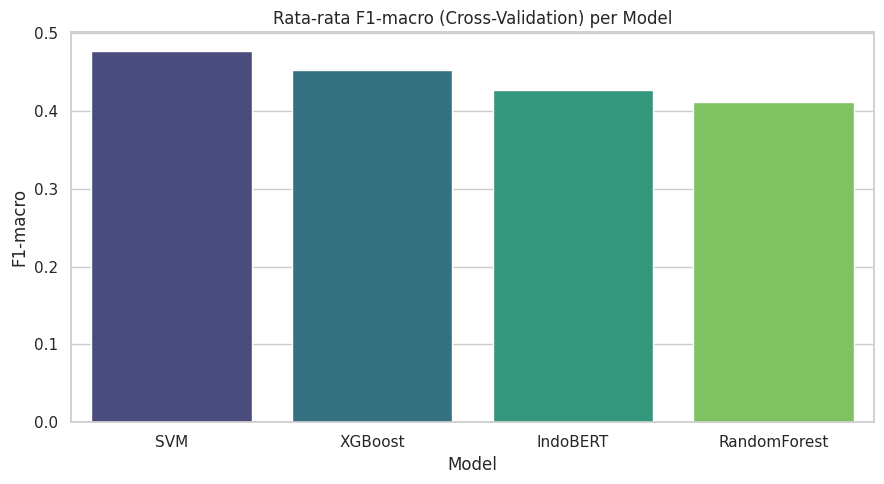

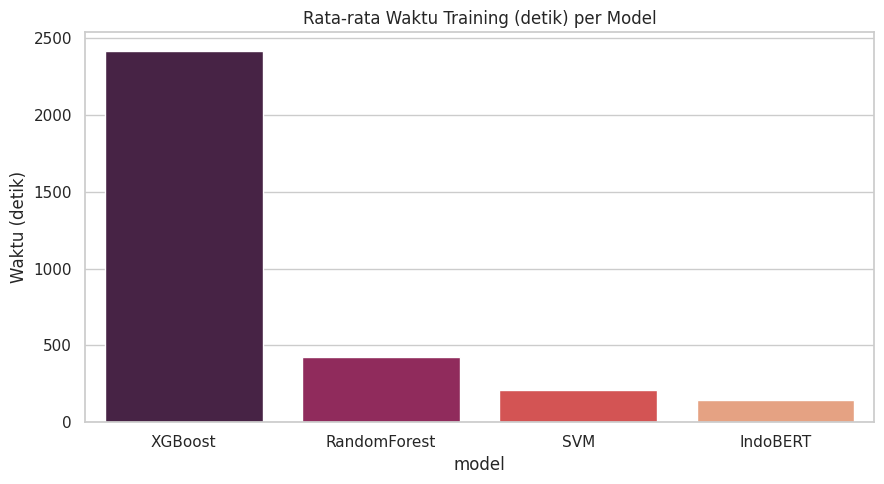

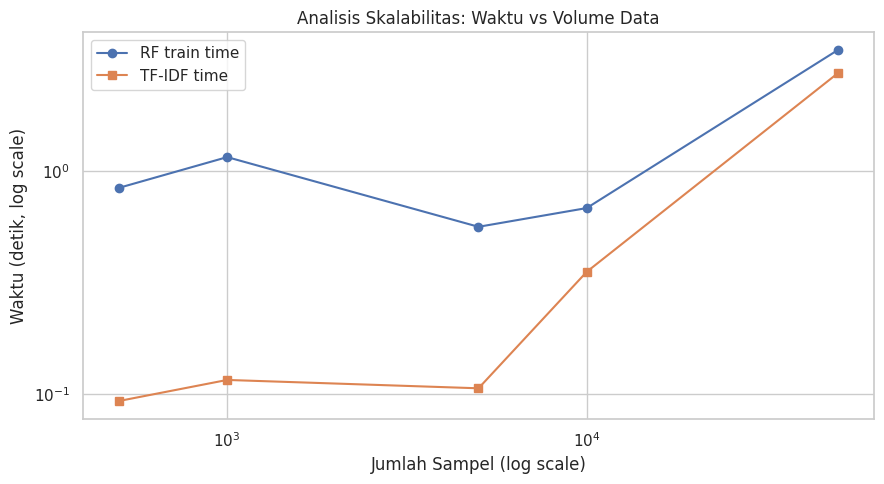

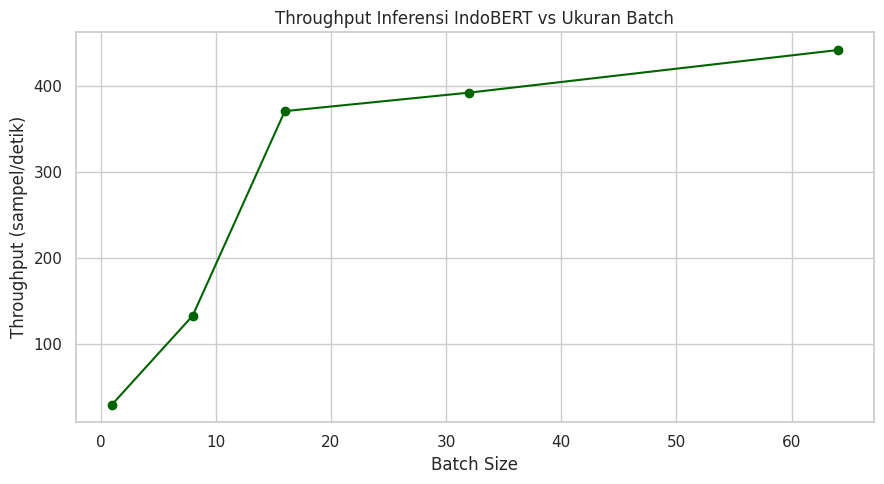


✅ Semua hasil & grafik tersimpan di: /content/drive/MyDrive/lia/outputs_depresi_id
File yang dihasilkan:
  - all_cv_results.csv
  - classical_cv_results.csv
  - indobert_balFalse
  - indobert_balTrue
  - indobert_cv_results.csv
  - indobert_shap_model
  - oom_boundary_results.csv
  - plot_f1_per_model.png
  - plot_scalability.png
  - plot_throughput.png
  - plot_train_time_per_model.png
  - robustness_results.csv
  - scalability_volume_results.csv
  - throughput_results.csv


In [30]:
sns.set_theme(style="whitegrid")

# --- Plot 1: Perbandingan F1-macro antar model ---
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = df_all_results.groupby("model")["f1_macro"].mean().sort_values(ascending=False)
sns.barplot(x=plot_data.index, y=plot_data.values, ax=ax, palette="viridis")
ax.set_title("Rata-rata F1-macro (Cross-Validation) per Model")
ax.set_ylabel("F1-macro")
ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_f1_per_model.png", dpi=150)
plt.show()

# --- Plot 2: Waktu training per model ---
fig, ax = plt.subplots(figsize=(9, 5))
plot_time = df_all_results.groupby("model")["train_time_s"].mean().sort_values(ascending=False)
sns.barplot(x=plot_time.index, y=plot_time.values, ax=ax, palette="rocket")
ax.set_title("Rata-rata Waktu Training (detik) per Model")
ax.set_ylabel("Waktu (detik)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_train_time_per_model.png", dpi=150)
plt.show()

# --- Plot 3: Skalabilitas (waktu vs volume data) ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_scalability["n_samples"], df_scalability["rf_train_time_s"], marker="o", label="RF train time")
ax.plot(df_scalability["n_samples"], df_scalability["tfidf_time_s"], marker="s", label="TF-IDF time")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Jumlah Sampel (log scale)")
ax.set_ylabel("Waktu (detik, log scale)")
ax.set_title("Analisis Skalabilitas: Waktu vs Volume Data")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_scalability.png", dpi=150)
plt.show()

# --- Plot 4: Throughput vs batch size ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_throughput["batch_size"], df_throughput["throughput_samples_per_s"], marker="o", color="darkgreen")
ax.set_xlabel("Batch Size")
ax.set_ylabel("Throughput (sampel/detik)")
ax.set_title("Throughput Inferensi IndoBERT vs Ukuran Batch")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_throughput.png", dpi=150)
plt.show()

print(f"\n✅ Semua hasil & grafik tersimpan di: {OUTPUT_DIR}")
print("File yang dihasilkan:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("  -", f)


## Penutup
Notebook ini mengimplementasikan **seluruh elemen** `04_Desain_Eksperimen.md` (jenis penelitian eksperimental komparatif, variabel terkontrol, skema validasi nested hold-out + 5-fold CV, tabel parameter, dan rencana stress testing) serta menguji ketiga hipotesis statistik pada `03_Proposal_Penelitian.md §9`.

**Langkah selanjutnya bagi pengguna:**
1. Ganti dataset sintetis dengan data riil hasil scraping & anotasi (Bagian 3).
2. Set `QUICK_DEMO_MODE = False` (Bagian 2) untuk menjalankan grid parameter penuh & 5-fold CV sesuai desain riset.
3. Pertimbangkan Colab Pro/Pro+ atau sesi runtime lebih panjang bila dataset besar (>10.000 sampel) untuk menghindari time-out sesi saat fine-tuning IndoBERT penuh (4 epoch × 5 fold × 2 kondisi balancing).
